<a href="https://colab.research.google.com/github/letruc271193-dot/project/blob/main/gpa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

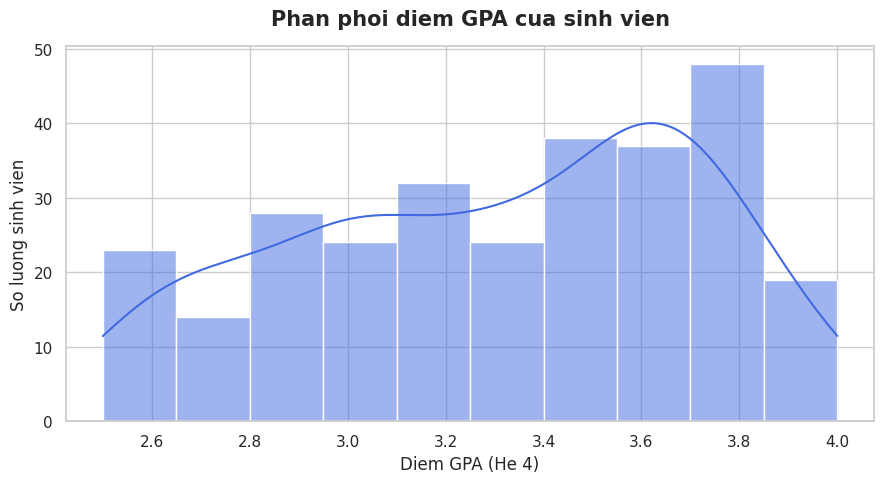

In [52]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Đọc dữ liệu (Đảm bảo file CSV đã được upload lên thanh bên trái của Colab)
df = pd.read_csv("Dự đoán GPA theo thói quen học tập - Câu trả lời biểu mẫu 1.csv")

# 2. Đổi tên cột cho ngắn gọn để code dễ thở hơn
col_mapping = {
    'Trung bình một tuần bạn dành bao nhiêu giờ để tự học/ôn bài? (Số)': 'GioTuHoc',
    'Học kỳ này bạn đang học bao nhiêu môn? (Số)': 'SoMonHoc',
    'Bạn có đi làm thêm (Part-time job) không?': 'DiLamThem',
    'Trung bình mỗi ngày bạn ngủ bao nhiêu tiếng? (Số)\n': 'GioNgu',
    'Bạn có đang tham gia Câu lạc bộ/Đội/Nhóm nào không? ': 'ThamGiaCLB',
    'Tỷ lệ tham gia các buổi học trên lớp (Attendance %) của bạn thường là bao nhiêu?': 'ChuyenCan',
    'Phong cách học tập chủ yếu của bạn là gì?': 'PhongCachHoc',
    'Trung bình mỗi ngày bạn dành bao nhiêu tiếng cho mạng xã hội (Facebook, TikTok, v.v.)? (Số)': 'GioMXH',
    'Điểm trung bình (GPA) hệ 4 của học kỳ gần nhất hoặc điểm tích lũy hiện tại của bạn là bao nhiêu? (Số - ví dụ: 3.5)': 'GPA'
}
df.rename(columns=col_mapping, inplace=True)

# 3. Tiền xử lý (Data Cleaning)
# Xóa các dòng không có điểm GPA
df.dropna(subset=['GPA'], inplace=True)
# Ép kiểu dữ liệu về dạng số, nếu ai nhập chữ bậy bạ sẽ biến thành NaN
for col in ['GioTuHoc', 'SoMonHoc', 'GioNgu', 'GioMXH', 'GPA']:
    df[col] = pd.to_numeric(df[col], errors='coerce')
# Xóa lần nữa để đảm bảo data sạch 100%
df.dropna(subset=['GPA'], inplace=True)

# 4. Tùy chỉnh giao diện biểu đồ
sns.set_theme(style="whitegrid")

# ==========================================
#  PHÂN PHỐI ĐIỂM GPA (Histogram)
# ==========================================
plt.figure(figsize=(9, 5))
sns.histplot(df['GPA'], kde=True, color='royalblue', bins=10)
plt.title('Phan phoi diem GPA cua sinh vien', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Diem GPA (He 4)')
plt.ylabel('So luong sinh vien')
plt.tight_layout()
plt.show()


/tmp/ipykernel_12854/2624708185.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='DiLamThem', y='GPA', data=df, palette='Set2')


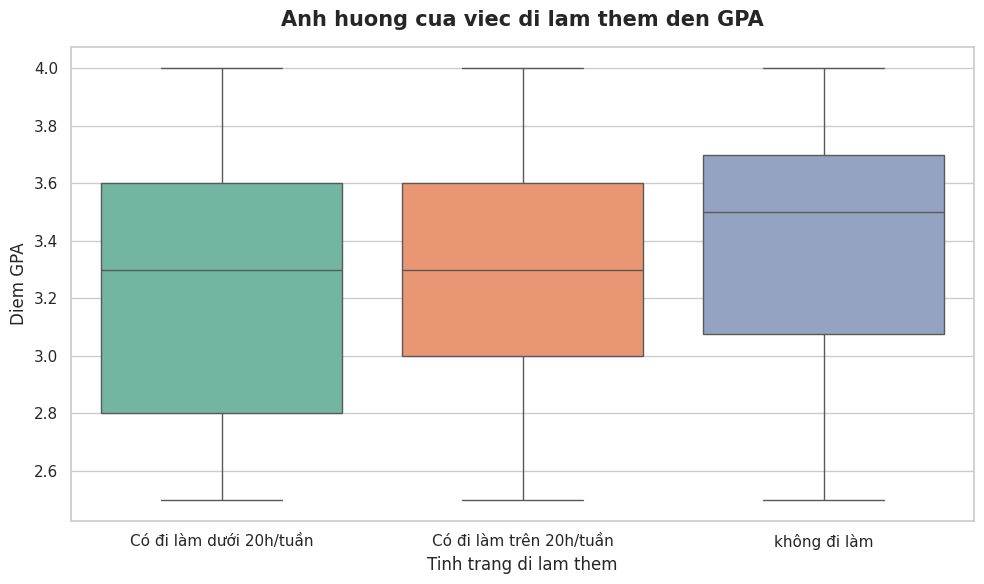

In [53]:
# ==========================================
#  BOXPLOT ẢNH HƯỞNG CỦA ĐI LÀM THÊM
# ==========================================
plt.figure(figsize=(10, 6))
sns.boxplot(x='DiLamThem', y='GPA', data=df, palette='Set2')
plt.title('Anh huong cua viec di lam them den GPA', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Tinh trang di lam them')
plt.ylabel('Diem GPA')
plt.tight_layout()
plt.show()



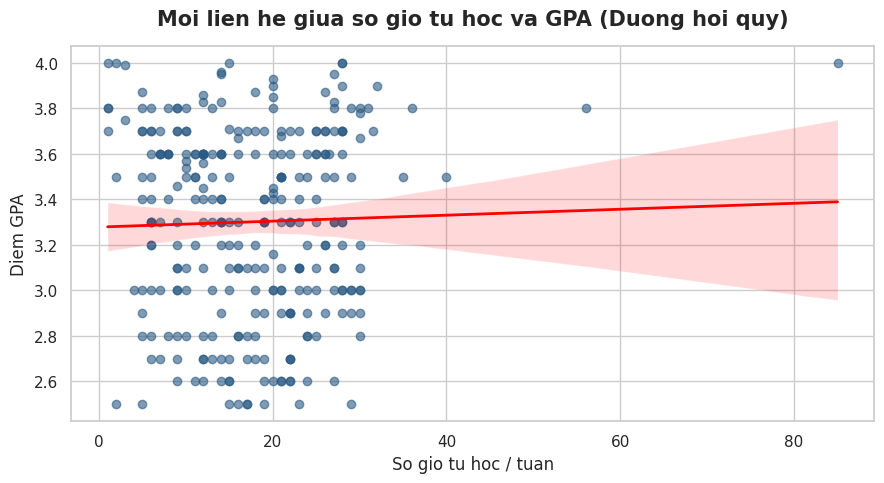

In [54]:
# ==========================================
#  SCATTER PLOT GIỜ TỰ HỌC & GPA
# ==========================================
plt.figure(figsize=(9, 5))
# Vẽ biểu đồ phân tán kèm đường hồi quy màu đỏ
sns.regplot(x='GioTuHoc', y='GPA', data=df, scatter_kws={'alpha':0.6, 'color':'#2b5b84'}, line_kws={'color':'red', 'linewidth': 2})
plt.title('Moi lien he giua so gio tu hoc va GPA (Duong hoi quy)', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('So gio tu hoc / tuan')
plt.ylabel('Diem GPA')
plt.tight_layout()
plt.show()

In [55]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 1. Mã hóa các biến phân loại (Chữ -> Số) để đưa vào mô hình Học máy
df_encoded = pd.get_dummies(df, drop_first=True)

# 2. Chia tách tập biến độc lập (X) và biến mục tiêu (y là GPA)
X = df_encoded.drop('GPA', axis=1)
y = df_encoded['GPA']

# 3. Phân chia dữ liệu: 80% để Huấn luyện (Train) - 20% để Kiểm thử (Test)
# (Theo đúng chuẩn của bài báo IEEE mẫu)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ==========================================
# MÔ HÌNH 1: HỒI QUY TUYẾN TÍNH (LINEAR REGRESSION)
# ==========================================
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("🏆 KẾT QUẢ MÔ HÌNH HỒI QUY TUYẾN TÍNH 🏆")
print(f"- R-squared (R2): {r2_score(y_test, y_pred_lr):.4f}")
print(f"- Sai số tuyệt đối trung bình (MAE): {mean_absolute_error(y_test, y_pred_lr):.4f}")
print(f"- Sai số bình phương trung bình (MSE): {mean_squared_error(y_test, y_pred_lr):.4f}\n")

# ==========================================
# MÔ HÌNH 2: RỪNG NGẪU NHIÊN (RANDOM FOREST)
# ==========================================
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("🌲 KẾT QUẢ MÔ HÌNH RANDOM FOREST 🌲")
print(f"- R-squared (R2): {r2_score(y_test, y_pred_rf):.4f}")
print(f"- Sai số tuyệt đối trung bình (MAE): {mean_absolute_error(y_test, y_pred_rf):.4f}")
print(f"- Sai số bình phương trung bình (MSE): {mean_squared_error(y_test, y_pred_rf):.4f}")

🏆 KẾT QUẢ MÔ HÌNH HỒI QUY TUYẾN TÍNH 🏆
- R-squared (R2): -0.6598
- Sai số tuyệt đối trung bình (MAE): 0.4450
- Sai số bình phương trung bình (MSE): 0.3262

🌲 KẾT QUẢ MÔ HÌNH RANDOM FOREST 🌲
- R-squared (R2): 0.2297
- Sai số tuyệt đối trung bình (MAE): 0.3191
- Sai số bình phương trung bình (MSE): 0.1514


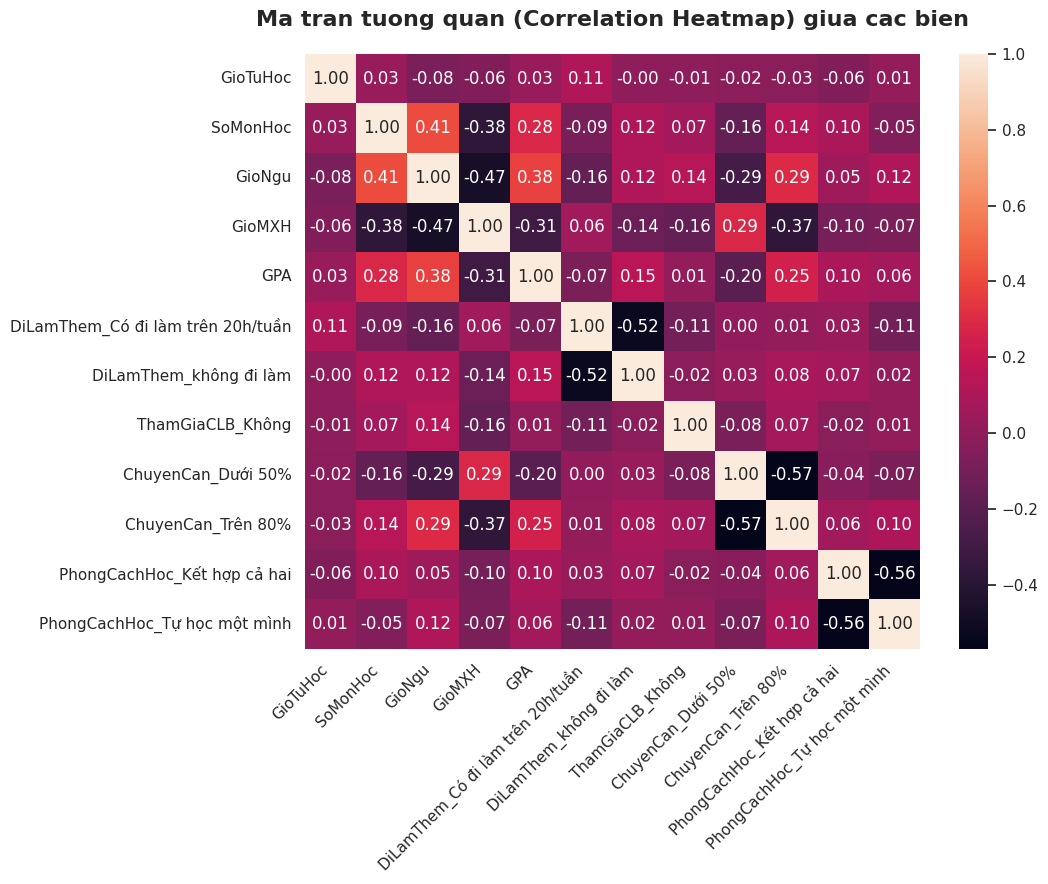

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor

# 1. Đọc dữ liệu (Đảm bảo file CSV đã được upload)
df = pd.read_csv("Dự đoán GPA theo thói quen học tập - Câu trả lời biểu mẫu 1.csv")

# 2. Đổi tên cột cho dễ xử lý
col_mapping = {
    'Dấu thời gian': 'Timestamp',
    'Trung bình một tuần bạn dành bao nhiêu giờ để tự học/ôn bài? (Số)': 'GioTuHoc',
    'Học kỳ này bạn đang học bao nhiêu môn? (Số)': 'SoMonHoc',
    'Bạn có đi làm thêm (Part-time job) không?': 'DiLamThem',
    'Trung bình mỗi ngày bạn ngủ bao nhiêu tiếng? (Số)\n': 'GioNgu',
    'Bạn có đang tham gia Câu lạc bộ/Đội/Nhóm nào không? ': 'ThamGiaCLB',
    'Tỷ lệ tham gia các buổi học trên lớp (Attendance %) của bạn thường là bao nhiêu?': 'ChuyenCan',
    'Phong cách học tập chủ yếu của bạn là gì?': 'PhongCachHoc',
    'Trung bình mỗi ngày bạn dành bao nhiêu tiếng cho mạng xã hội (Facebook, TikTok, v.v.)? (Số)': 'GioMXH',
    'Điểm trung bình (GPA) hệ 4 của học kỳ gần nhất hoặc điểm tích lũy hiện tại của bạn là bao nhiêu? (Số - ví dụ: 3.5)': 'GPA'
}
df.rename(columns=col_mapping, inplace=True)
df.drop('Timestamp', axis=1, inplace=True, errors='ignore')

# 3. Tiền xử lý dữ liệu
df.dropna(subset=['GPA'], inplace=True)
for col in ['GioTuHoc', 'SoMonHoc', 'GioNgu', 'GioMXH', 'GPA']:
    df[col] = pd.to_numeric(df[col], errors='coerce')
df.dropna(subset=['GPA'], inplace=True)
for col in ['GioTuHoc', 'SoMonHoc', 'GioNgu', 'GioMXH']:
    df[col] = df[col].fillna(df[col].median())

# 4. Mã hóa biến phân loại (Chữ -> Số)
df_encoded = pd.get_dummies(df, drop_first=True)

# Cài đặt giao diện nền trắng cho biểu đồ
sns.set_theme(style="whitegrid")

# ==========================================
#  MA TRẬN TƯƠNG QUAN (KIỂU VUÔNG CƠ BẢN)
# ==========================================
plt.figure(figsize=(11, 9))
corr = df_encoded.corr()

# Xóa lệnh mask đi, vẽ Full dạng vuông, dùng màu mặc định của thư viện
sns.heatmap(corr, annot=True, fmt=".2f")

plt.title('Ma tran tuong quan (Correlation Heatmap) giua cac bien', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

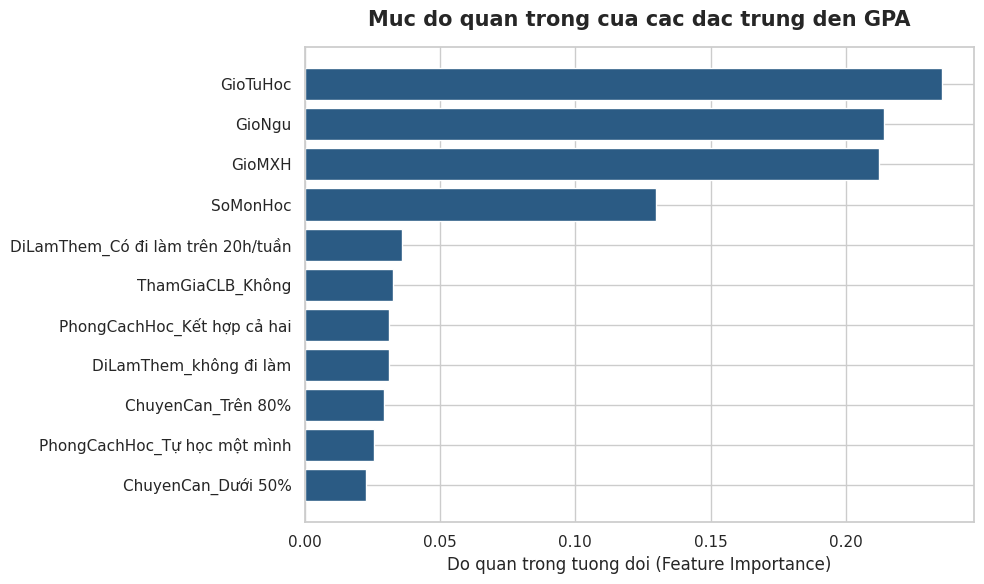

In [57]:
# ==========================================
# MỨC ĐỘ QUAN TRỌNG (FEATURE IMPORTANCE)
# ==========================================
X = df_encoded.drop('GPA', axis=1)
y = df_encoded['GPA']

# Chạy mô hình Random Forest để đánh giá biến
rf = RandomForestRegressor(random_state=42, n_estimators=100)
rf.fit(X, y)

# Lấy ra mức độ quan trọng và sắp xếp
importances = rf.feature_importances_
indices = np.argsort(importances)
features = X.columns

plt.figure(figsize=(10, 6))
plt.title('Muc do quan trong cua cac dac trung den GPA', fontsize=15, fontweight='bold', pad=15)
plt.barh(range(len(indices)), importances[indices], color='#2b5b84', align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.xlabel('Do quan trong tuong doi (Feature Importance)')
plt.tight_layout()
plt.show()

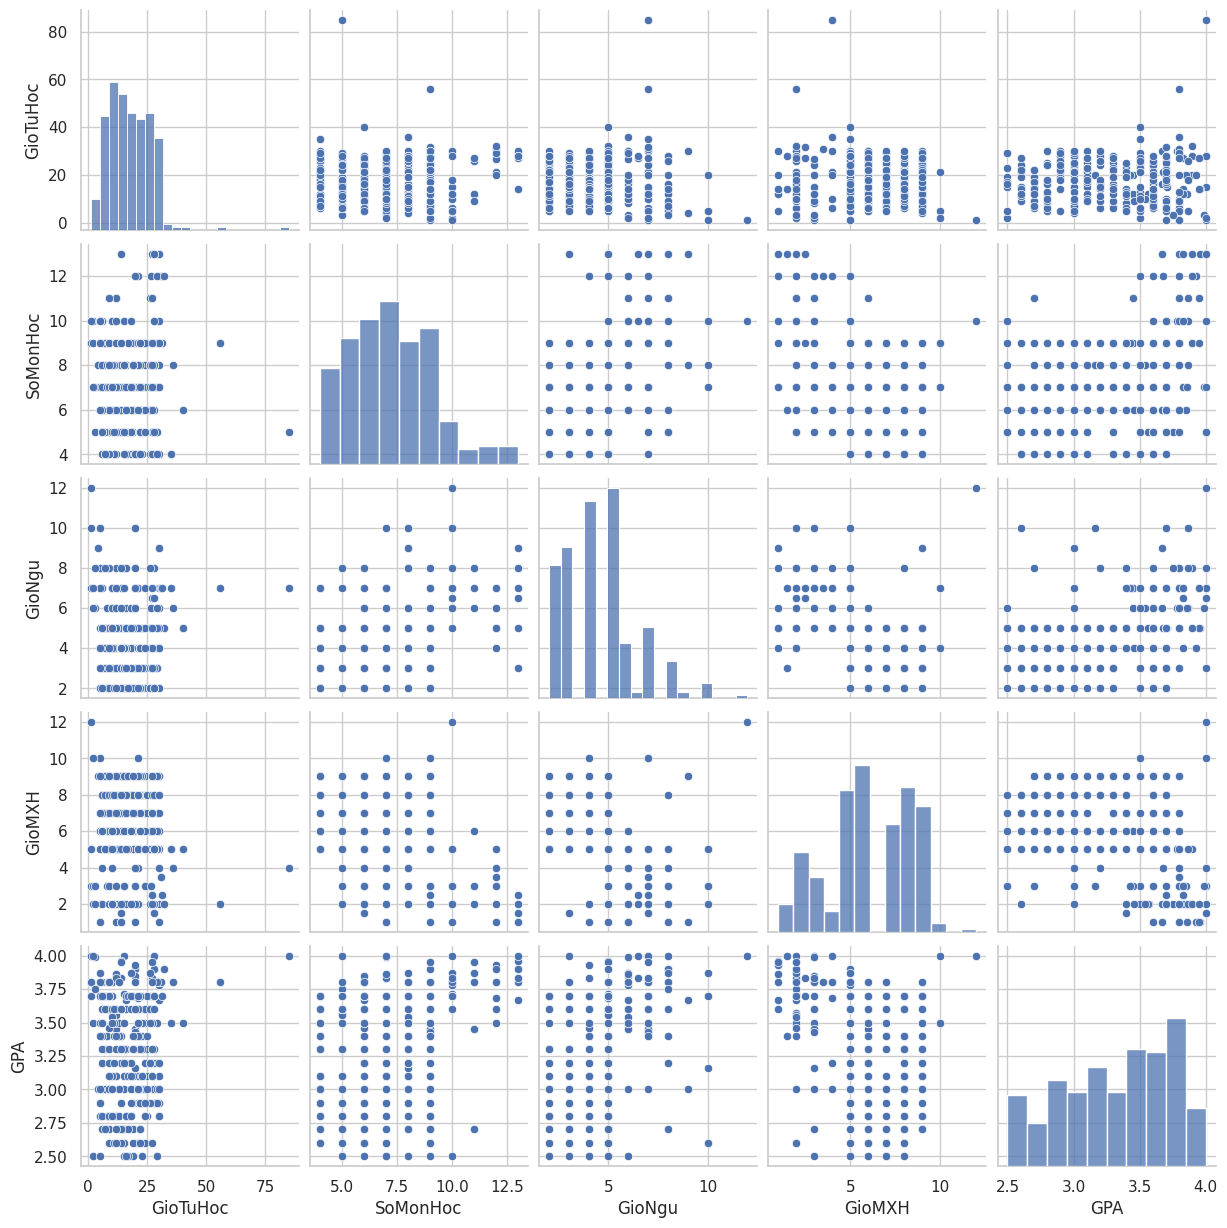

In [58]:
sns.pairplot(df)
# Biểu đồ 4